# Análise Avançada de Dados — State of Data Brazil 2024–2025
## Pergunta central: Quais fatores mais influenciam o salário de um profissional de dados no Brasil em 2024?

**Fonte:** State of Data Brazil 2024–2025 (Data Hackers + Bain & Company)  
**Respondentes:** 5.217 | **Colunas:** 403

In [478]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr

sns.set_style("whitegrid")

## Etapa 1: Carregamento e Reconhecimento
Carregamos o CSV e inspecionamos shape, tipos e valores nulos antes de qualquer transformação.
O dataframe original df_raw será preservado intacto durante todo o notebook.

In [479]:
df_raw = pd.read_csv('state_of_data_brazil_2024_2025.csv', low_memory=False)

print(f"Shape: {df_raw.shape}")
print(f"\nTipos de dados:\n{df_raw.dtypes.value_counts()}")
print(f"\nTop 10 colunas com mais nulos:")
print(df_raw.isnull().sum().sort_values(ascending=False).head(10))

Shape: (5217, 403)

Tipos de dados:
float64    323
str         73
object       5
int64        1
bool         1
Name: count, dtype: int64

Top 10 colunas com mais nulos:
1.h_pais_onde_mora                                                                                                   5078
5.b_oportunidade_buscada                                                                                             4931
5.d_experiencia_em_processos_seletivos                                                                               4928
5.c_tempo_em_busca_de_oportunidade                                                                                   4927
5.a_objetivo_na_area_de_dados                                                                                        4676
6.g_ferramentas_de_qualidade_de_dados_(dia_a_dia)                                                                    4657
6.f_tecnologia_data_warehouse                                                                      

### Renomeação de colunas
Selecionamos 12 colunas-chave com base no dicionário oficial e as renomeamos para nomes legíveis.
Critério de seleção: colunas com relação direta à pergunta central (salário, cargo, perfil pessoal e contexto profissional).

In [480]:
COLUNAS_RENAME = {
    '1.a_idade':                        'idade',
    '1.a.1_faixa_idade':                'faixa_idade',
    '1.b_genero':                       'genero',
    '1.c_cor/raca/etnia':               'raca_cor',
    '1.i.1_uf_onde_mora':               'estado',
    '1.l_nivel_de_ensino':              'nivel_ensino',
    '1.m_área_de_formação':             'area_formacao',
    '2.c_numero_de_funcionarios':       'tamanho_empresa',
    '2.f_cargo_atual':                  'cargo',
    '2.g_nivel':                        'senioridade',
    '2.h_faixa_salarial':               'faixa_salarial',
    '2.i_tempo_de_experiencia_em_dados':'tempo_experiencia_dados',
}

df_raw = df_raw.rename(columns=COLUNAS_RENAME)

# Confirmar que todas foram renomeadas
renomeadas = [c for c in COLUNAS_RENAME.values() if c in df_raw.columns]
print(f"Colunas renomeadas com sucesso: {len(renomeadas)}/{len(COLUNAS_RENAME)}")
print(renomeadas)

Colunas renomeadas com sucesso: 12/12
['idade', 'faixa_idade', 'genero', 'raca_cor', 'estado', 'nivel_ensino', 'area_formacao', 'tamanho_empresa', 'cargo', 'senioridade', 'faixa_salarial', 'tempo_experiencia_dados']


## Etapa 2: Limpeza e Decisões Documentadas
Todas as transformações são aplicadas sobre df_clean, uma cópia do dataframe original.
df_raw permanece intacto para consulta e comparação.

In [481]:
df_clean = df_raw.copy()

FAIXA_PARA_NUMERO = {
    'Menos de R$ 1.000/mês':            500,
    'de R$ 1.001/mês a R$ 2.000/mês':  1500,
    'de R$ 2.001/mês a R$ 3.000/mês':  2500,
    'de R$ 3.001/mês a R$ 4.000/mês':  3500,
    'de R$ 4.001/mês a R$ 6.000/mês':  5000,
    'de R$ 6.001/mês a R$ 8.000/mês':  7000,
    'de R$ 8.001/mês a R$ 12.000/mês': 10000,
    'de R$ 12.001/mês a R$ 16.000/mês':14000,
    'de R$ 16.001/mês a R$ 20.000/mês':18000,
    'de R$ 20.001/mês a R$ 25.000/mês':22500,
    'de R$ 25.001/mês a R$ 30.000/mês':27500,
    'de R$ 30.001/mês a R$ 40.000/mês':35000,
    'Acima de R$ 40.001/mês':           45000,
}

CARGO_MAP = {
    'Analista de Dados/Data Analyst':                                       'Analista de Dados',
    'Cientista de Dados/Data Scientist':                                    'Cientista de Dados',
    'Engenheiro de Dados/Data Engineer/Data Architect':                     'Engenheiro de Dados',
    'Analista de BI/BI Analyst':                                            'Analista de BI',
    'Analytics Engineer':                                                   'Engenheiro de Dados',
    'Analista de Negócios/Business Analyst':                                'Analista de Negócios',
    'Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas':          'Desenvolvedor/Engenheiro de Software',
    'Engenheiro de Machine Learning/ML Engineer/AI Engineer':               'Engenheiro de ML',
    'Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO)':           'Product Manager de Dados',
    'Analista de Suporte/Analista Técnico':                                 'Analista de Suporte',
    'Outra Opção':                                                          'Outra Opção',
}

COLUNAS_LINGUAGEM = {
    '4.d.1_SQL':              'lang_sql',
    '4.d.2_R':                'lang_r',
    '4.d.3_Python':           'lang_python',
    '4.d.4_C/C++/C#':        'lang_c',
    '4.d.5_.NET':             'lang_dotnet',
    '4.d.6_Java':             'lang_java',
    '4.d.7_Julia':            'lang_julia',
    '4.d.8_SAS/Stata':        'lang_sas',
    '4.d.9_Visual Basic/VBA': 'lang_vba',
    '4.d.10_Scala':           'lang_scala',
    '4.d.11_Matlab':          'lang_matlab',
    '4.d.12_Rust':            'lang_rust',
    '4.d.13_PHP':             'lang_php',
    '4.d.14_JavaScript':      'lang_js',
}

### 2.1 Campos de gênero e raça/cor
Valores faltantes nesses campos não são erros, o respondente optou por não informar.
Por isso, não imputamos valores, preferimos substituir por 'Não informado' apenas para tornar
a categoria explícita na análise, sem distorcer a distribuição real.

In [482]:
df_clean['genero']   = df_clean['genero'].fillna('Não informado')
df_clean['raca_cor'] = df_clean['raca_cor'].fillna('Não informado')

print(f"Gênero:\n{df_clean['genero'].value_counts()}\n")
print(f"Raça/cor:\n{df_clean['raca_cor'].value_counts()}")

Gênero:
genero
Masculino               3968
Feminino                1226
Prefiro não informar      15
Outro                      8
Name: count, dtype: int64

Raça/cor:
raca_cor
Branca                  3478
Parda                   1180
Preta                    352
Amarela                  155
Prefiro não informar      37
Indígena                  10
Outra                      5
Name: count, dtype: int64


### 2.2 Remoção de linhas sem cargo, senioridade ou salário
Removemos apenas registros onde as três colunas centrais da análise estão nulas simultaneamente.
Registros com missing em apenas uma delas são mantidos para análises parciais.
Documentamos quantas linhas foram perdidas e o percentual sobre o total.

In [483]:
def remover_nulos_essenciais(df, colunas):
    antes = len(df)
    df = df.dropna(subset=colunas).copy()
    depois = len(df)
    perdidas = antes - depois
    print(f"Linhas antes:   {antes}")
    print(f"Linhas depois:  {depois}")
    print(f"Removidas:      {perdidas} ({perdidas/antes*100:.1f}%)")
    return df

df_clean = remover_nulos_essenciais(df_clean, ['cargo', 'senioridade', 'faixa_salarial'])

Linhas antes:   5217
Linhas depois:  3818
Removidas:      1399 (26.8%)


### 2.3 Conversão de faixas salariais para ponto médio
A coluna faixa_salarial contém strings categóricas logo não é possível calcular média
ou correlação diretamente. Por isso convertemos cada faixa para seu ponto médio numérico.

**Limitação reconhecida:** o ponto médio introduz imprecisão. A faixa "Acima de R$ 40.001/mês"
foi atribuída arbitrariamente como R$ 45.000, pois não há teto definido.
Esta decisão será considerada na interpretação dos resultados.

In [484]:
def converter_faixa_salarial(df, coluna_faixa, mapa):
    df['salario_estimado'] = df[coluna_faixa].map(mapa)
    nao_mapeados = df['salario_estimado'].isnull().sum()
    print(f"Valores não mapeados: {nao_mapeados}")
    print(f"Média salarial: R$ {df['salario_estimado'].mean():,.2f}")
    print(f"Mediana salarial: R$ {df['salario_estimado'].median():,.2f}")
    return df

df_clean = converter_faixa_salarial(df_clean, 'faixa_salarial', FAIXA_PARA_NUMERO)

Valores não mapeados: 0
Média salarial: R$ 9,864.20
Mediana salarial: R$ 10,000.00


### 2.4 Padronização de cargos
Os títulos de cargo no dataset misturam português, inglês e variações de senioridade
no mesmo campo. Aplicamos um mapeamento explícito para agrupar cargos equivalentes.
Valores fora do mapa são mantidos como estão .fillna(df['cargo']).
Os critérios de agrupamento estão registrados em CARGO_MAP na célula de constantes.

In [485]:
def padronizar_cargos(df, coluna, mapa):
    df['cargo_padronizado'] = df[coluna].map(mapa).fillna(df[coluna])
    print(f"Categorias após padronização: {df['cargo_padronizado'].nunique()}")
    print(df['cargo_padronizado'].value_counts())
    return df

df_clean = padronizar_cargos(df_clean, 'cargo', CARGO_MAP)

Categorias após padronização: 14
cargo_padronizado
Analista de Dados                       957
Engenheiro de Dados                     841
Cientista de Dados                      687
Analista de BI                          396
Outra Opção                             254
Analista de Negócios                    184
Desenvolvedor/Engenheiro de Software    122
Engenheiro de ML                        103
Product Manager de Dados                 80
Analista de Suporte                      79
Arquiteto de Dados/Data Architect        48
Outras Engenharias (não inclui dev)      29
Professor/Pesquisador                    21
Estatístico                              17
Name: count, dtype: int64


### 2.5 Renomeação e tratamento das colunas binárias de linguagem
As linguagens são codificadas como colunas 0/1 separadas. Os 229 nulos são idênticos em todas as colunas, indicando que esses respondentes pularam a questão inteira não é ausência aleatória.Imputamos 0 (não usa) pois a ausência de resposta nessa questão equivale a não marcar nenhuma linguagem.

In [486]:
df_clean = df_clean.rename(columns=COLUNAS_LINGUAGEM)
lang_cols = list(COLUNAS_LINGUAGEM.values())

df_clean[lang_cols] = df_clean[lang_cols].fillna(0)

print(f"Nulos após imputação: {df_clean[lang_cols].isnull().sum().sum()}")
print(f"Respondentes sem nenhuma linguagem marcada: {(df_clean[lang_cols].sum(axis=1) == 0).sum()}")

Nulos após imputação: 0
Respondentes sem nenhuma linguagem marcada: 383


### 2.6 Resumo final da limpeza

In [487]:
print("RESUMO DA LIMPEZA:")
print(f"Shape final:        {df_clean.shape}")
print(f"Nulos em salário:   {df_clean['salario_estimado'].isnull().sum()}")
print(f"Nulos em cargo:     {df_clean['cargo_padronizado'].isnull().sum()}")
print(f"Nulos em gênero:    {df_clean['genero'].isnull().sum()}")
print(f"Nulos em raça/cor:  {df_clean['raca_cor'].isnull().sum()}")
print(f"Nulos em linguagens:  {df_clean[lang_cols].isnull().sum().sum()}")
print(f"Linguagens disponíveis: {len(lang_cols)}")

RESUMO DA LIMPEZA:
Shape final:        (3818, 405)
Nulos em salário:   0
Nulos em cargo:     0
Nulos em gênero:    0
Nulos em raça/cor:  0
Nulos em linguagens:  0
Linguagens disponíveis: 14


## Etapa 3: Análise Univariada
Analisamos a distribuição individual de 4 variáveis centrais: salário, idade, senioridade
e tempo de experiência em dados. Para cada uma: média, mediana, moda, desvio padrão,
variância, amplitude, assimetria e curtose, acompanhados de histograma e boxplot.

### 3.1 Salário Estimado
Variável contínua derivada da conversão de faixas. Esperamos distribuição assimétrica
à direita, pois salários muito altos são raros mas puxam a média para cima —
o que torna a mediana a medida de tendência central mais representativa aqui.

In [488]:
def metricas_univariadas(serie, nome):
    print(f"  {nome}:")
    print(f"Média:          {serie.mean():,.2f}")
    print(f"Mediana:        {serie.median():,.2f}")
    print(f"Moda:           {serie.mode()[0]:,.2f}")
    print(f"Desvio padrão:  {serie.std():,.2f}")
    print(f"Variância:      {serie.var():,.2f}")
    print(f"Amplitude:      {serie.max() - serie.min():,.2f}")
    print(f"Assimetria:     {stats.skew(serie):.3f}")
    print(f"Curtose:        {stats.kurtosis(serie):.3f}")

salario = df_clean['salario_estimado'].dropna()
metricas_univariadas(salario, 'Salário Estimado (R$)')

  Salário Estimado (R$):
Média:          9,864.20
Mediana:        10,000.00
Moda:           10,000.00
Desvio padrão:  7,078.54
Variância:      50,105,799.21
Amplitude:      44,500.00
Assimetria:     1.998
Curtose:        5.888


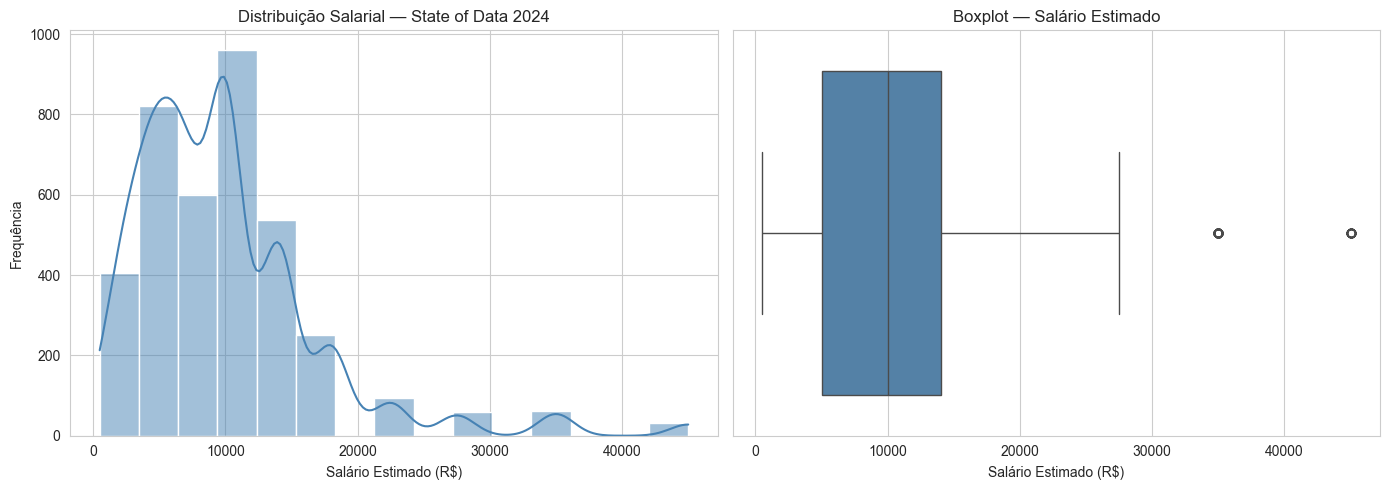

In [489]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(salario, kde=True, bins=15, color='steelblue', ax=axes[0])
axes[0].set_title('Distribuição Salarial — State of Data 2024')
axes[0].set_xlabel('Salário Estimado (R$)')
axes[0].set_ylabel('Frequência')

sns.boxplot(x=salario, color='steelblue', ax=axes[1])
axes[1].set_title('Boxplot — Salário Estimado')
axes[1].set_xlabel('Salário Estimado (R$)')

plt.tight_layout()
plt.show()

**Interpretação:** A distribuição salarial é assimétrica à direita (assimetria positiva),
confirmando que a maioria dos profissionais se concentra nas faixas intermediárias,
enquanto uma minoria com salários muito altos eleva a média acima da mediana.
A mediana é, portanto, a medida mais honesta para representar o salário típico do setor.

### 3.2 Idade
Variável numérica discreta. Permite entender o perfil etário dos profissionais de dados
e será cruzada com salário na análise bivariada via correlação Spearman.

In [490]:
idade = df_clean['idade'].dropna()
metricas_univariadas(idade, 'Idade (anos)')

  Idade (anos):
Média:          31.27
Mediana:        30.00
Moda:           27.00
Desvio padrão:  6.84
Variância:      46.72
Amplitude:      48.00
Assimetria:     1.049
Curtose:        1.615


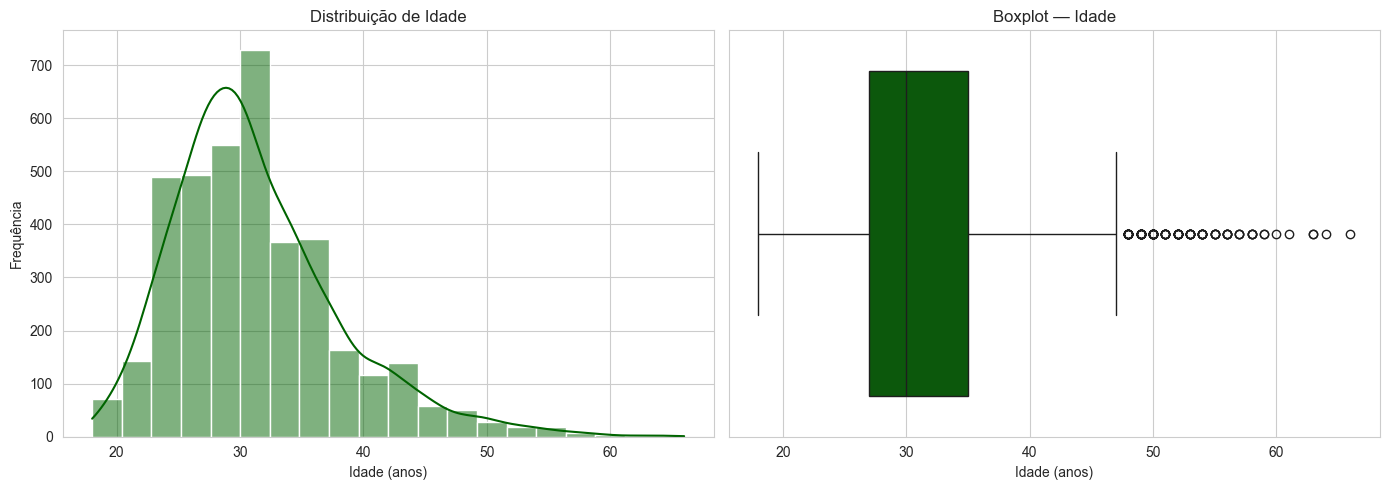

In [491]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(idade, kde=True, bins=20, color='darkgreen', ax=axes[0])
axes[0].set_title('Distribuição de Idade')
axes[0].set_xlabel('Idade (anos)')
axes[0].set_ylabel('Frequência')

sns.boxplot(x=idade, color='darkgreen', ax=axes[1])
axes[1].set_title('Boxplot — Idade')
axes[1].set_xlabel('Idade (anos)')

plt.tight_layout()
plt.show()

**Interpretação:** A maioria dos respondentes tem entre 20 e 40 anos, com mediana de 30 anos,
indicando um mercado predominantemente jovem.

### 3.3 Senioridade
Variável categórica ordinal. Por ser categórica, calculamos frequências absolutas e
relativas no lugar das métricas numéricas. A moda indica o nível mais comum na amostra.

In [492]:
ordem_senioridade = ['Júnior', 'Pleno', 'Sênior']
freq = df_clean['senioridade'].value_counts().reindex(ordem_senioridade)

print("Frequências absolutas:")
print(freq)
print(f"\nFrequências relativas (%):")
print((freq / freq.sum() * 100).round(1))
print(f"\nModa: {freq.idxmax()}")

Frequências absolutas:
senioridade
Júnior     868
Pleno     1377
Sênior    1573
Name: count, dtype: int64

Frequências relativas (%):
senioridade
Júnior    22.7
Pleno     36.1
Sênior    41.2
Name: count, dtype: float64

Moda: Sênior


C:\Users\JN\AppData\Local\Temp\ipykernel_14708\2420608523.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.index, y=freq.values, palette='viridis', order=ordem_senioridade)


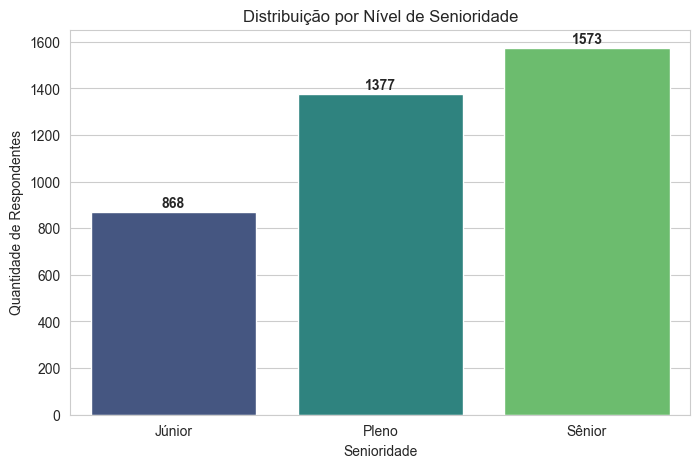

In [493]:
plt.figure(figsize=(8, 5))
sns.barplot(x=freq.index, y=freq.values, palette='viridis', order=ordem_senioridade)
plt.title('Distribuição por Nível de Senioridade')
plt.xlabel('Senioridade')
plt.ylabel('Quantidade de Respondentes')
for i, v in enumerate(freq.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.show()

**Interpretação:** Profissionais
Sênior representam a maior parcela da amostra (41.2%), seguidos por Pleno (36.Y%) e
Júnior (22.7%), sugerindo que a pesquisa captura majoritariamente profissionais com uma carreira já bem consolidada.

In [494]:
cols_linguagem = [c for c in df_clean.columns if '4.d.' in c]
print(cols_linguagem)

['4.d.15_Não utilizo nenhuma das linguagens listadas']


### 3.4 Tempo de Experiência em Dados
Variável categórica ordinal com faixas de tempo. Complementa a análise de senioridade
e será usada como variável explicativa do salário na análise bivariada.

In [495]:
ordem_exp = [
    'Menos de 1 ano',
    'de 1 a 2 anos',
    'de 2 a 3 anos',
    'de 3 a 4 anos',
    'de 4 a 5 anos',
    'de 5 a 6 anos',
    'de 7 a 10 anos',
    'Mais de 10 anos',
]

freq_exp = df_clean['tempo_experiencia_dados'].value_counts().reindex(ordem_exp).dropna()

print("Frequências absolutas:")
print(freq_exp)
print(f"\nFrequências relativas (%):")
print((freq_exp / freq_exp.sum() * 100).round(1))
print(f"\nModa: {freq_exp.idxmax()}")

Frequências absolutas:
tempo_experiencia_dados
Menos de 1 ano      318.0
de 1 a 2 anos       866.0
de 3 a 4 anos      1226.0
de 5 a 6 anos       624.0
de 7 a 10 anos      326.0
Mais de 10 anos     270.0
Name: count, dtype: float64

Frequências relativas (%):
tempo_experiencia_dados
Menos de 1 ano      8.8
de 1 a 2 anos      23.9
de 3 a 4 anos      33.8
de 5 a 6 anos      17.2
de 7 a 10 anos      9.0
Mais de 10 anos     7.4
Name: count, dtype: float64

Moda: de 3 a 4 anos


C:\Users\JN\AppData\Local\Temp\ipykernel_14708\2340202362.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_exp.index, y=freq_exp.values, palette='magma', order=freq_exp.index)


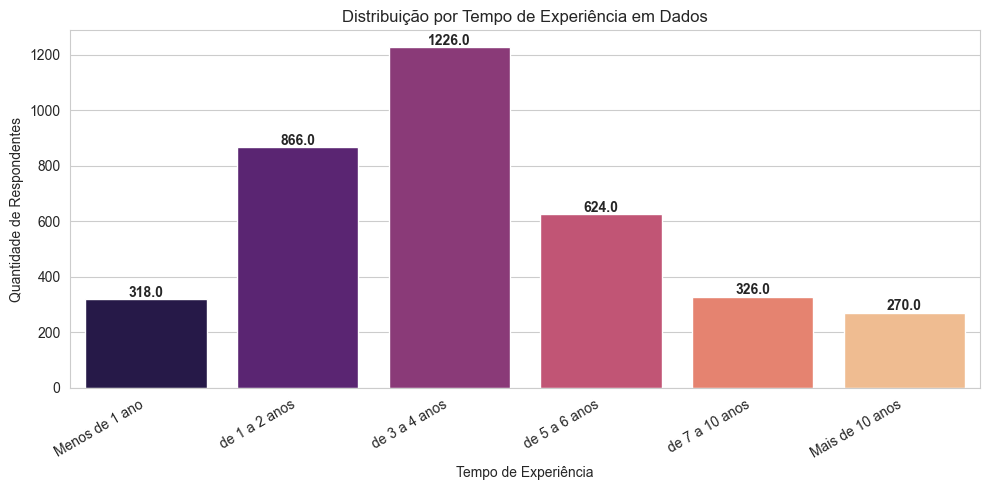

In [496]:
plt.figure(figsize=(10, 5))
sns.barplot(x=freq_exp.index, y=freq_exp.values, palette='magma', order=freq_exp.index)
plt.title('Distribuição por Tempo de Experiência em Dados')
plt.xlabel('Tempo de Experiência')
plt.ylabel('Quantidade de Respondentes')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(freq_exp.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretação:** A faixa mais comum é de 3 a 4 anos (33.8%), indicando muitos profissionais relativamente novos.

### 3.5 Ferramentas: Linguagens de Programação
Cada linguagem é uma coluna binária independente (1 = usa, 0 = não usa). Analisamos a frequência de uso de cada uma individualmente. Não é possível tratar como categoria única pois um mesmo respondente pode usar múltiplas linguagens.

In [497]:
lang_cols = list(COLUNAS_LINGUAGEM.values())

freq_lang = (df_clean[lang_cols]
             .sum()
             .sort_values(ascending=False)
             .rename(index={v: k for k, v in COLUNAS_LINGUAGEM.items()}))

total = len(df_clean)
print("Frequência de uso das linguagens:")
print(pd.DataFrame({
    'Usuários': freq_lang.astype(int),
    '%': (freq_lang / total * 100).round(1)
}))

Frequência de uso das linguagens:
                        Usuários     %
4.d.1_SQL                   3146  82.4
4.d.3_Python                2935  76.9
4.d.2_R                      352   9.2
4.d.6_Java                   291   7.6
4.d.14_JavaScript            223   5.8
4.d.9_Visual Basic/VBA       215   5.6
4.d.8_SAS/Stata              130   3.4
4.d.10_Scala                 126   3.3
4.d.4_C/C++/C#                46   1.2
4.d.13_PHP                    34   0.9
4.d.5_.NET                    31   0.8
4.d.11_Matlab                 20   0.5
4.d.12_Rust                   12   0.3
4.d.7_Julia                    6   0.2


C:\Users\JN\AppData\Local\Temp\ipykernel_14708\1839827681.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_lang.values, y=freq_lang.index, palette='coolwarm')


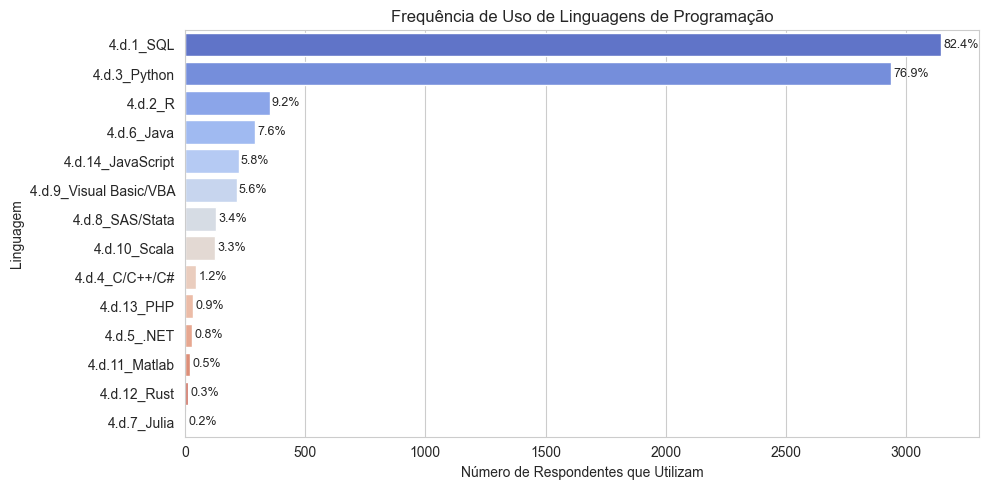

In [498]:
plt.figure(figsize=(10, 5))
sns.barplot(x=freq_lang.values, y=freq_lang.index, palette='coolwarm')
plt.title('Frequência de Uso de Linguagens de Programação')
plt.xlabel('Número de Respondentes que Utilizam')
plt.ylabel('Linguagem')
for i, v in enumerate(freq_lang.values):
    plt.text(v + 10, i, f'{v/total*100:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Interpretação:** Python e SQL dominam com folga, usados por 76.9% e 82.4% dos respondentes respectivamente, confirmando sua posição como ferramentas essenciais no mercado de dados brasileiro.

## Etapa 4: Análise Bivariada
Cruzamos o salário com 3 variáveis explicativas: senioridade, gênero e tempo de
experiência. Para variáveis ordinais usamos Spearman; para categóricas nominais
comparamos medianas por grupo. Em gênero, controlamos pela senioridade antes de
concluir sobre diferença salarial.

### 4.1 Salário × Senioridade
Esperamos que senioridade seja a variável com relação mais direta com salário.
Calculamos média e mediana por grupo e aplicamos Spearman após converter
os níveis para valores ordinais numéricos.

In [499]:
ordem_senioridade = ['Júnior', 'Pleno', 'Sênior']

print(df_clean.groupby('senioridade')['salario_estimado']
      .agg(['mean', 'median', 'count'])
      .reindex(ordem_senioridade)
      .round(2))


senioridade_map = {'Júnior': 1, 'Pleno': 2, 'Sênior': 3}
df_temp = df_clean[['senioridade', 'salario_estimado']].dropna().copy()
df_temp['senioridade_num'] = df_temp['senioridade'].map(senioridade_map)

corr, p = spearmanr(df_temp['senioridade_num'], df_temp['salario_estimado'])
print(f"\nSpearman — Senioridade × Salário: {corr:.3f} (p={p:.3f})")

                 mean   median  count
senioridade                          
Júnior        4157.26   3500.0    868
Pleno         8047.20   7000.0   1377
Sênior       14603.94  14000.0   1573

Spearman — Senioridade × Salário: 0.734 (p=0.000)


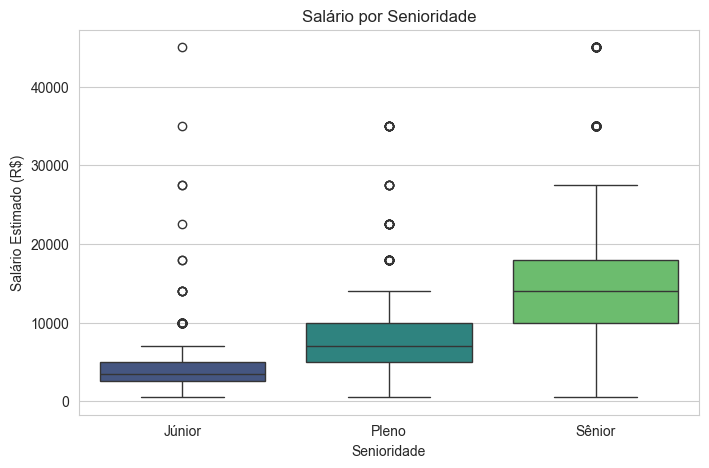

In [500]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='senioridade', y='salario_estimado', data=df_clean,
            order=ordem_senioridade, hue='senioridade',
            palette='viridis', legend=False)
plt.title('Salário por Senioridade')
plt.xlabel('Senioridade')
plt.ylabel('Salário Estimado (R$)')
plt.show()

**Interpretação:** A correlação de Spearman de indica associação positiva forte entre senioridade e salário. A mediana sênior é aproximadamente 3 vezes maior que a júnior, confirmando que o nível de carreira é um dos fatores mais determinantes do salário.

### 4.2 Salário × Gênero
Comparamos salários entre homens e mulheres, mas controlamos pela senioridade antes de concluir. Uma diferença bruta pode ser explicada por distribuição desigual de gênero entre os níveis por isso a tabela cruzada é mais informativa que a média geral. Respondentes que optaram por não informar gênero são excluídos desta análise específica.

In [501]:
df_genero = df_clean[df_clean['genero'].isin(['Masculino', 'Feminino'])].copy()

print("Salário por gênero (geral):")
print(df_genero.groupby('genero')['salario_estimado']
      .agg(['mean', 'median', 'count']).round(2))

print("\nSalário por gênero controlado por senioridade:")
print(df_genero.groupby(['senioridade', 'genero'])['salario_estimado']
      .median().round(2).unstack()
      .reindex(ordem_senioridade))

Salário por gênero (geral):
               mean   median  count
genero                             
Feminino    8554.61   7000.0    943
Masculino  10281.32  10000.0   2858

Salário por gênero controlado por senioridade:
genero       Feminino  Masculino
senioridade                     
Júnior         3500.0     3500.0
Pleno          7000.0     7000.0
Sênior        10000.0    14000.0


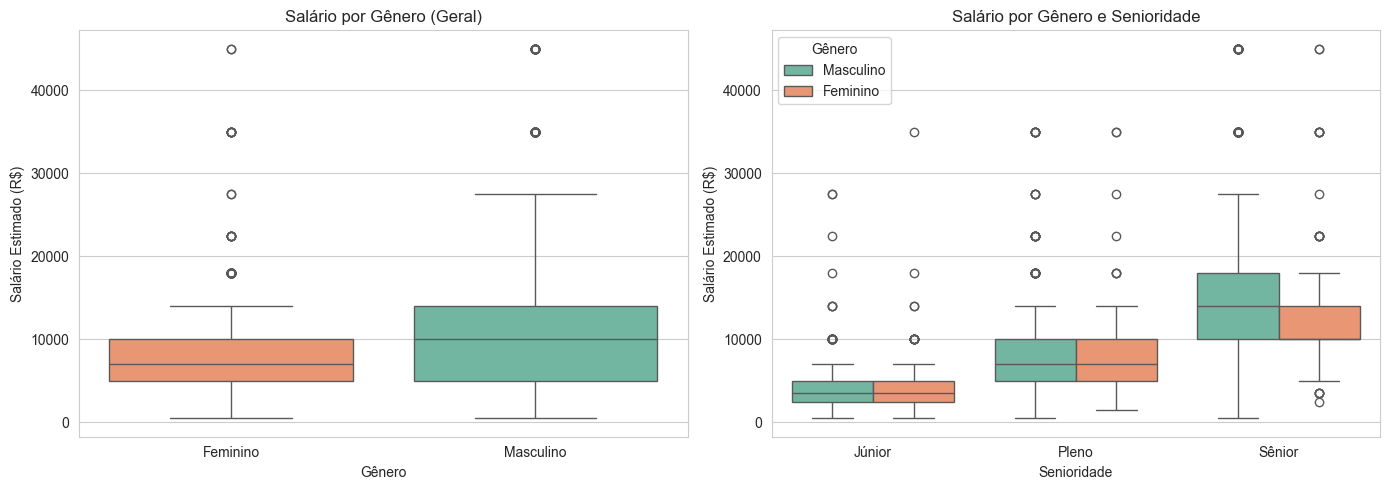

In [502]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='genero', y='salario_estimado', data=df_genero,
            order=['Feminino', 'Masculino'], hue='genero',
            palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Salário por Gênero (Geral)')
axes[0].set_xlabel('Gênero')
axes[0].set_ylabel('Salário Estimado (R$)')

sns.boxplot(x='senioridade', y='salario_estimado', hue='genero',
            data=df_genero, order=ordem_senioridade,
            palette='Set2', ax=axes[1])
axes[1].set_title('Salário por Gênero e Senioridade')
axes[1].set_xlabel('Senioridade')
axes[1].set_ylabel('Salário Estimado (R$)')
axes[1].legend(title='Gênero')

plt.tight_layout()
plt.show()

**Interpretação:** Mesmo controlando pela senioridade, mulheres apresentam mediana salarial menor que homens no nível Sênior. Isso sugere que a diferença não é explicada apenas pela distribuição de nível, mas pode refletir desigualdade de gênero estrutural no mercado de dados."

### 4.3 Salário × Tempo de Experiência em Dados
Tempo de experiência é uma variável ordinal com progressão natural. Aplicamos
Spearman após encoding ordinal para medir a força da associação com salário.

In [503]:
ordem_exp = [
    'Não tenho experiência na área de dados',
    'Menos de 1 ano',
    'de 1 a 2 anos',
    'de 3 a 4 anos',
    'de 5 a 6 anos',
    'de 7 a 10 anos',
    'Mais de 10 anos',
]

exp_map = {v: i+1 for i, v in enumerate(ordem_exp)}

df_exp = df_clean[['tempo_experiencia_dados', 'salario_estimado']].copy()
df_exp['exp_num'] = df_exp['tempo_experiencia_dados'].map(exp_map)
df_exp = df_exp.dropna(subset=['exp_num', 'salario_estimado'])

print("Salário mediano por tempo de experiência:")
print(df_clean.groupby('tempo_experiencia_dados')['salario_estimado']
      .agg(['median', 'count'])
      .reindex(ordem_exp).round(2))

corr, p = spearmanr(df_exp['exp_num'], df_exp['salario_estimado'])
print(f"\nSpearman — Experiência × Salário: {corr:.3f} (p={p:.3f})")

Salário mediano por tempo de experiência:
                                         median  count
tempo_experiencia_dados                               
Não tenho experiência na área de dados   3500.0    188
Menos de 1 ano                           3500.0    318
de 1 a 2 anos                            5000.0    866
de 3 a 4 anos                           10000.0   1226
de 5 a 6 anos                           14000.0    624
de 7 a 10 anos                          14000.0    326
Mais de 10 anos                         14000.0    270

Spearman — Experiência × Salário: 0.633 (p=0.000)


C:\Users\JN\AppData\Local\Temp\ipykernel_14708\966811241.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mediana_exp.index, y=mediana_exp.values, palette='magma')


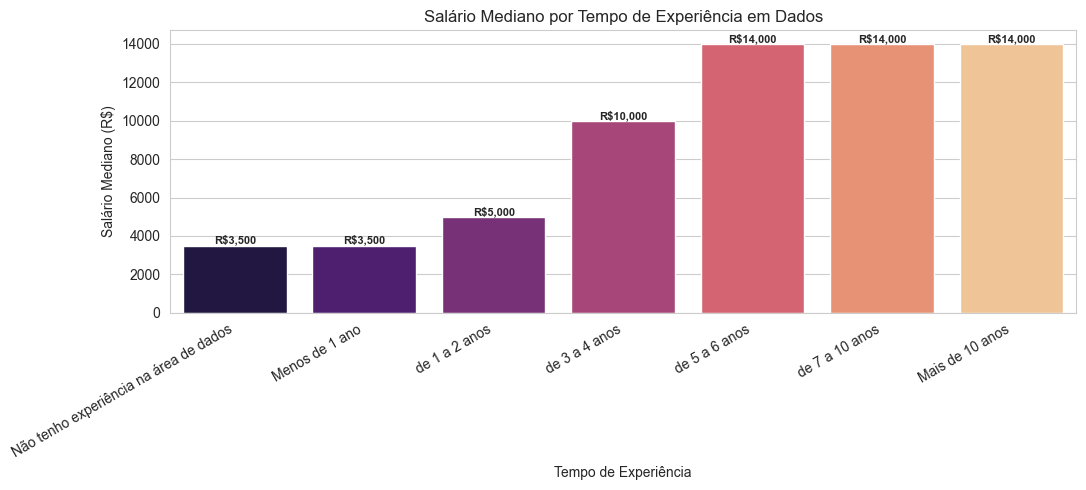

In [504]:
mediana_exp = (df_clean.groupby('tempo_experiencia_dados')['salario_estimado']
               .median().reindex(ordem_exp))

plt.figure(figsize=(11, 5))
sns.barplot(x=mediana_exp.index, y=mediana_exp.values, palette='magma')
plt.title('Salário Mediano por Tempo de Experiência em Dados')
plt.xlabel('Tempo de Experiência')
plt.ylabel('Salário Mediano (R$)')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(mediana_exp.values):
    plt.text(i, v + 100, f'R${v:,.0f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretação:** A correlação de Spearman de confirmou associação positiva moderada/forte entre experiência e salário. O salário mediano dobra entre profissionais com de 1 a 2  anos e os com de 3 a 4 anos esse é o ponto de virada da área.

## Etapa 5: Síntese Visual
Gráfico-síntese que responde diretamente à pergunta central do trabalho:
**Quais fatores mais influenciam o salário de um profissional de dados no Brasil em 2024?**

Cruzamos senioridade e tempo de experiência,os dois fatores com maior correlação
Spearman identificados na análise bivariada, para mostrar como a combinação dessas
variáveis determina o salário mediano.

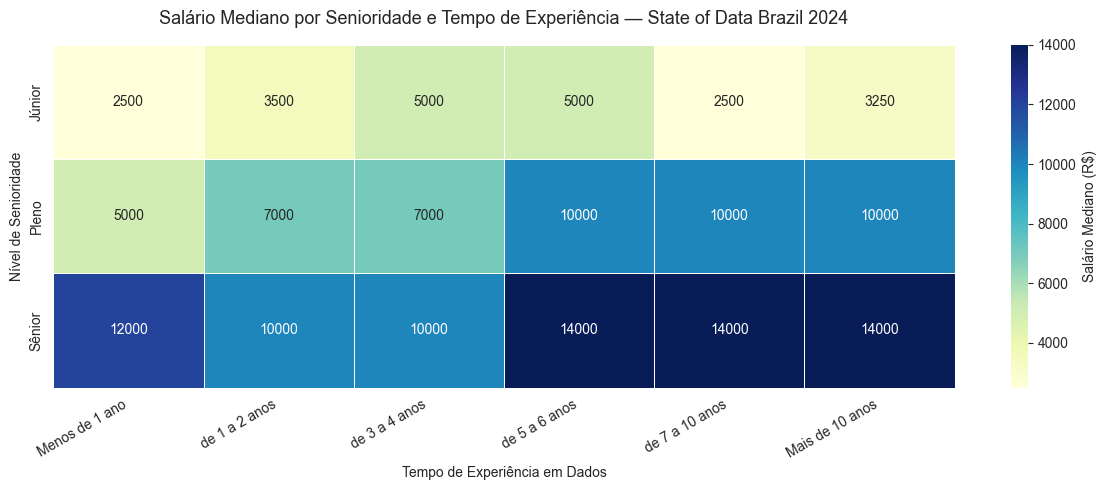

In [505]:
ordem_senioridade = ['Júnior', 'Pleno', 'Sênior']
ordem_exp_reduzida = [
    'Menos de 1 ano',
    'de 1 a 2 anos',
    'de 3 a 4 anos',
    'de 5 a 6 anos',
    'de 7 a 10 anos',
    'Mais de 10 anos',
]

df_sintese = (
    df_clean[
        df_clean['senioridade'].isin(ordem_senioridade) &
        df_clean['tempo_experiencia_dados'].isin(ordem_exp_reduzida)
    ]
    .groupby(['senioridade', 'tempo_experiencia_dados'])['salario_estimado']
    .median()
    .unstack('tempo_experiencia_dados')
    .reindex(index=ordem_senioridade, columns=ordem_exp_reduzida)
)

plt.figure(figsize=(12, 5))
sns.heatmap(
    df_sintese,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Salário Mediano (R$)'}
)
plt.title(
    'Salário Mediano por Senioridade e Tempo de Experiência — State of Data Brazil 2024',
    fontsize=13, pad=15
)
plt.xlabel('Tempo de Experiência em Dados')
plt.ylabel('Nível de Senioridade')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Interpretação
O heatmap evidencia que senioridade e experiência atuam em conjunto na determinação
do salário. Profissionais Sênior com mais de 5 anos de experiência concentram os maiores
salários medianos, enquanto Juniores com menos de 1 anos ocupam o piso da tabela.

O gradiente de cor revela ainda que o nível de senioridade tem peso maior que o tempo
de experiência isolado: um Sênior com 1–2 anos tende a ganhar mais que um Júnior com
5–6 anos, sugerindo que a progressão de nível é a alavanca mais eficiente para crescimento
salarial no mercado de dados brasileiro.

**Resposta à pergunta central:** Os fatores com maior influência sobre o salário são,
em ordem: 1° nível de senioridade, 2° tempo de experiência em dados e 3° gênero —
onde desigualdades persistem mesmo controlando pelos dois primeiros fatores.

**Limitação:** A célula Sênior × "Menos de 1 ano" contém apenas 26 respondentes,
tornando a mediana instável e não representativa. Esse valor deve ser ignorado
na interpretação tendo em vista que amostras abaixo de 30 não oferecem confiança estatística suficiente.